# Credit Card Fraud Detection - Data Exploration
## Exploratory Data Analysis and Preprocessing

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

In [3]:
# Load data
df = pd.read_csv('../data/creditcard.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
# Class distribution
class_counts = df['Class'].value_counts()
print(f'Class distribution:\n{class_counts}')
print(f'\nFraud percentage: {class_counts[1]/len(df)*100:.4f}%')

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


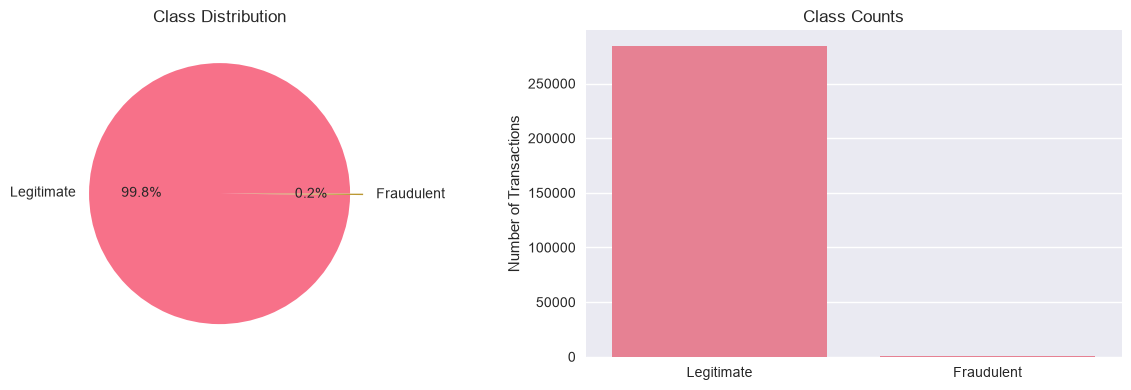

In [6]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(class_counts, labels=['Legitimate', 'Fraudulent'], autopct='%1.1f%%', explode=(0, 0.1))
axes[0].set_title('Class Distribution')

# Bar plot
sns.barplot(x=['Legitimate', 'Fraudulent'], y=class_counts.values, ax=axes[1])
axes[1].set_title('Class Counts')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [7]:
# Feature statistics
print('Statistical summary:')
df.describe()

Statistical summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


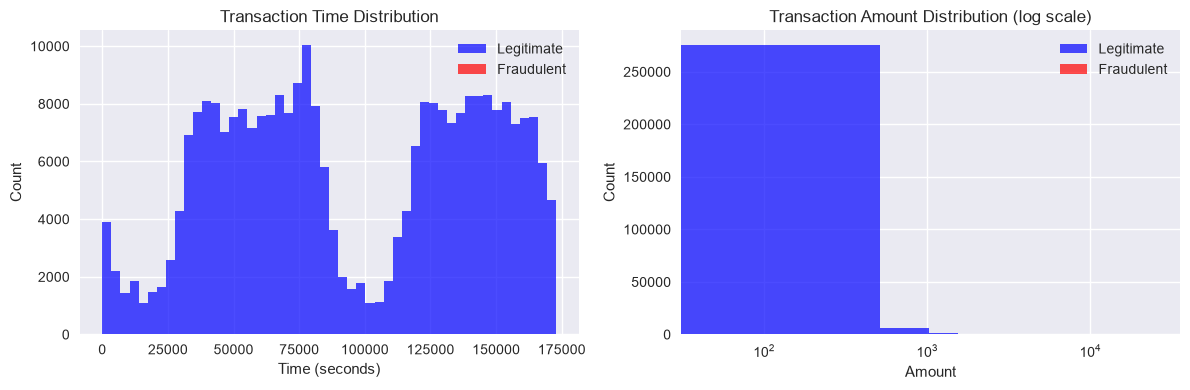

In [8]:
# Analyze Time feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time distribution
axes[0].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.7, label='Legitimate', color='blue')
axes[0].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.7, label='Fraudulent', color='red')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Time Distribution')
axes[0].legend()

# Amount distribution (log scale)
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Legitimate', color='blue')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraudulent', color='red')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')
axes[1].set_title('Transaction Amount Distribution (log scale)')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

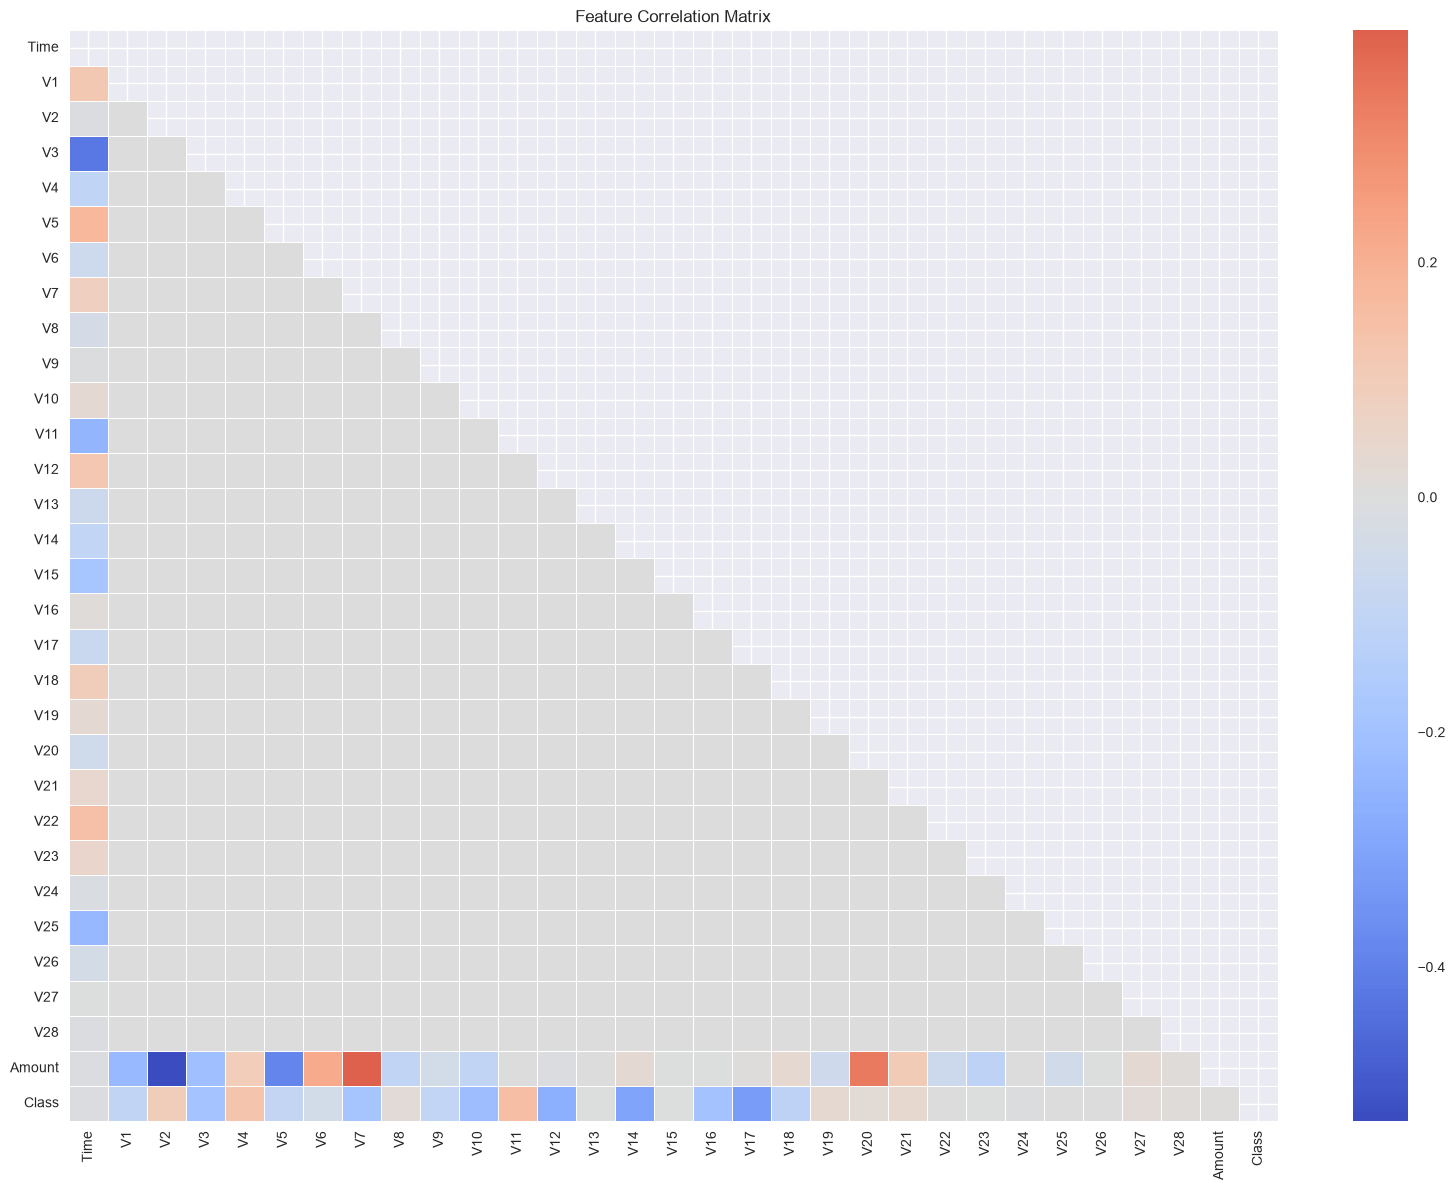

In [9]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, cmap='coolwarm', center=0, linewidths=0.5, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Preprocessing
X = df.drop('Class', axis=1)
y = df['Class']

# Scale 'Amount' and 'Time'
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')

Training set: 227845 samples
Test set: 56962 samples

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [11]:
# Save processed data
import joblib

joblib.dump(X_train, '../data/X_train.pkl')
joblib.dump(X_test, '../data/X_test.pkl')
joblib.dump(y_train, '../data/y_train.pkl')
joblib.dump(y_test, '../data/y_test.pkl')
joblib.dump(scaler, '../data/scaler.pkl')

print('Data saved successfully!')

Data saved successfully!
